# Chapter 1 — Introduction
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §1

Sequential decision making · Canonical models (MDP, POMDP, bandits) · RL taxonomy

In [1]:
%pip install -q numpy matplotlib
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


## 1.1 Sequential Decision Making

Agent–environment loop:
$$s_{t+1}\sim p(\cdot\mid s_t,a_t),\quad r_t=r(s_t,a_t)$$

Goal: maximise $\mathbb{E}\bigl[\sum_{t=0}^\infty\gamma^t r_t\bigr]$.

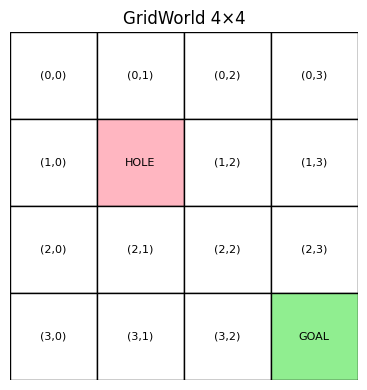

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    """4x4 deterministic grid. Goal (3,3)=+1, Hole (1,1)=-1. Actions: 0=U,1=D,2=L,3=R."""
    SIZE = 4
    GOAL, HOLE = (3, 3), (1, 1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]

    def __init__(self, gamma=0.99):
        self.gamma = gamma
        self.pos = (0, 0)

    def reset(self):
        self.pos = (0, 0)
        return self.idx(self.pos)

    def step(self, a):
        r, c = self.pos
        dr, dc = self.MOVES[a]
        self.pos = (max(0, min(self.SIZE-1, r+dr)),
                    max(0, min(self.SIZE-1, c+dc)))
        if self.pos == self.GOAL: return self.idx(self.pos),  1.0, True
        if self.pos == self.HOLE: return self.idx(self.pos), -1.0, True
        return self.idx(self.pos), -0.01, False

    def step_from(self, pos, a):
        old = self.pos; self.pos = pos
        s, r, done = self.step(a)
        result = (self.pos, r, done)
        self.pos = old
        return result

    def idx(self, pos):  return pos[0]*self.SIZE + pos[1]
    def pos_of(self, i): return (i//self.SIZE, i%self.SIZE)
    def n_states(self):  return self.SIZE**2
    def n_actions(self): return 4

def render(ax, title="GridWorld 4×4"):
    ax.set_xlim(0,4); ax.set_ylim(0,4); ax.set_aspect("equal")
    ax.set_title(title); ax.axis("off")
    for r in range(4):
        for c in range(4):
            col = "#90EE90" if (r,c)==(3,3) else "#FFB6C1" if (r,c)==(1,1) else "white"
            lbl = "GOAL" if (r,c)==(3,3) else "HOLE" if (r,c)==(1,1) else f"({r},{c})"
            ax.add_patch(patches.Rectangle((c,3-r),1,1,ec="black",fc=col))
            ax.text(c+.5, 3.5-r, lbl, ha="center", va="center", fontsize=8)

fig, ax = plt.subplots(figsize=(4,4))
render(ax)
plt.tight_layout(); plt.show()


## 1.2 Canonical Models

| Model | Description |
|-------|-------------|
| **MDP** | $(\mathcal{S},\mathcal{A},p,r,\gamma)$ — fully observed |
| **POMDP** | MDP + observation model $p(o\mid s)$ |
| **Contextual bandit** | MDP with horizon $T=1$ per context |

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    """4x4 deterministic grid. Goal (3,3)=+1, Hole (1,1)=-1. Actions: 0=U,1=D,2=L,3=R."""
    SIZE = 4
    GOAL, HOLE = (3, 3), (1, 1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]

    def __init__(self, gamma=0.99):
        self.gamma = gamma
        self.pos = (0, 0)

    def reset(self):
        self.pos = (0, 0)
        return self.idx(self.pos)

    def step(self, a):
        r, c = self.pos
        dr, dc = self.MOVES[a]
        self.pos = (max(0, min(self.SIZE-1, r+dr)),
                    max(0, min(self.SIZE-1, c+dc)))
        if self.pos == self.GOAL: return self.idx(self.pos),  1.0, True
        if self.pos == self.HOLE: return self.idx(self.pos), -1.0, True
        return self.idx(self.pos), -0.01, False

    def step_from(self, pos, a):
        old = self.pos; self.pos = pos
        s, r, done = self.step(a)
        result = (self.pos, r, done)
        self.pos = old
        return result

    def idx(self, pos):  return pos[0]*self.SIZE + pos[1]
    def pos_of(self, i): return (i//self.SIZE, i%self.SIZE)
    def n_states(self):  return self.SIZE**2
    def n_actions(self): return 4

env = GridWorld()
S, A = env.n_states(), env.n_actions()

# Build deterministic T[s,a,s'] and R[s,a] tables
T = np.zeros((S, A, S))
R = np.zeros((S, A))
for s in range(S):
    p = env.pos_of(s)
    for a in range(A):
        ns_pos, r, _ = env.step_from(p, a)
        T[s, a, env.idx(ns_pos)] = 1.0
        R[s, a] = r

print("Transition table shape:", T.shape)
print("Reward table (first 8 states):")
print(R[:8].round(2))


Transition table shape: (16, 4, 16)
Reward table (first 8 states):
[[-0.01 -0.01 -0.01 -0.01]
 [-0.01 -1.   -0.01 -0.01]
 [-0.01 -0.01 -0.01 -0.01]
 [-0.01 -0.01 -0.01 -0.01]
 [-0.01 -0.01 -0.01 -1.  ]
 [-0.01 -0.01 -0.01 -0.01]
 [-0.01 -0.01 -1.   -0.01]
 [-0.01 -0.01 -0.01 -0.01]]


## 1.3 RL Taxonomy

| Approach | Core idea |
|----------|-----------|
| **Value-based** | Learn $V^*(s)$ or $Q^*(s,a)$ → derive $\pi$ |
| **Policy-based** | Directly optimise $\pi_\theta$ via gradient |
| **Model-based** | Learn $\hat{p}(s'\mid s,a)$; plan inside model |

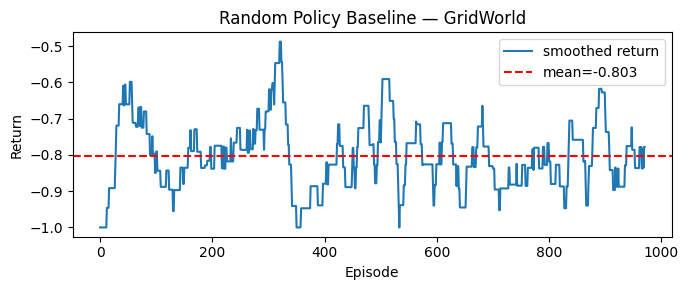

Random policy: mean=-0.803, std=0.543


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    """4x4 deterministic grid. Goal (3,3)=+1, Hole (1,1)=-1. Actions: 0=U,1=D,2=L,3=R."""
    SIZE = 4
    GOAL, HOLE = (3, 3), (1, 1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]

    def __init__(self, gamma=0.99):
        self.gamma = gamma
        self.pos = (0, 0)

    def reset(self):
        self.pos = (0, 0)
        return self.idx(self.pos)

    def step(self, a):
        r, c = self.pos
        dr, dc = self.MOVES[a]
        self.pos = (max(0, min(self.SIZE-1, r+dr)),
                    max(0, min(self.SIZE-1, c+dc)))
        if self.pos == self.GOAL: return self.idx(self.pos),  1.0, True
        if self.pos == self.HOLE: return self.idx(self.pos), -1.0, True
        return self.idx(self.pos), -0.01, False

    def step_from(self, pos, a):
        old = self.pos; self.pos = pos
        s, r, done = self.step(a)
        result = (self.pos, r, done)
        self.pos = old
        return result

    def idx(self, pos):  return pos[0]*self.SIZE + pos[1]
    def pos_of(self, i): return (i//self.SIZE, i%self.SIZE)
    def n_states(self):  return self.SIZE**2
    def n_actions(self): return 4

def random_rollout(n=1000, max_steps=200):
    env = GridWorld()
    returns = []
    for _ in range(n):
        env.reset(); G = 0; gt = 1.0
        for _ in range(max_steps):
            _, r, done = env.step(np.random.randint(4))
            G += gt*r; gt *= env.gamma
            if done: break
        returns.append(G)
    return returns

rets = random_rollout()
smooth = lambda x, w=30: np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(7,3))
plt.plot(smooth(rets), label="smoothed return")
plt.axhline(np.mean(rets), color="red", ls="--", label=f"mean={np.mean(rets):.3f}")
plt.xlabel("Episode"); plt.ylabel("Return")
plt.title("Random Policy Baseline — GridWorld")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Random policy: mean={np.mean(rets):.3f}, std={np.std(rets):.3f}")
